In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import spearmanr

## Data from ProteinGym https://proteingym.org/

In [2]:
pg_predictions = pd.read_csv("../data/pg_predictions_with_esm.csv")

## Compute correlations by method within assay

In [3]:
dms_corr = {}
for exp in pg_predictions.file.unique():
    experiment = exp.split("_")[0]
    if experiment == "S22A1":
        experiment += "_" + exp.split("_")[4].title()
    elif experiment == "A4":
        experiment += "_Aggregation"
    else:
        experiment += "_Growth"
    exp_res = {}
    for method in ["CADD_Score", "VEST_Score", "MutPred_Score", "CAPICE_score", "HMMER3", "ESM 1b", "ESM2 650m"]:
        method_name = method.split("_")[0] if "_" in method else method
        exp_res[method_name] = np.abs(spearmanr(pg_predictions[pg_predictions.file == exp][["DMS_score", method]].dropna()).statistic)
    dms_corr[experiment] = exp_res

## Averaged over all assays

In [4]:
colors = ["midnightblue", "tomato", "goldenrod", "cadetblue", "darkslategray", "firebrick", "seagreen"]

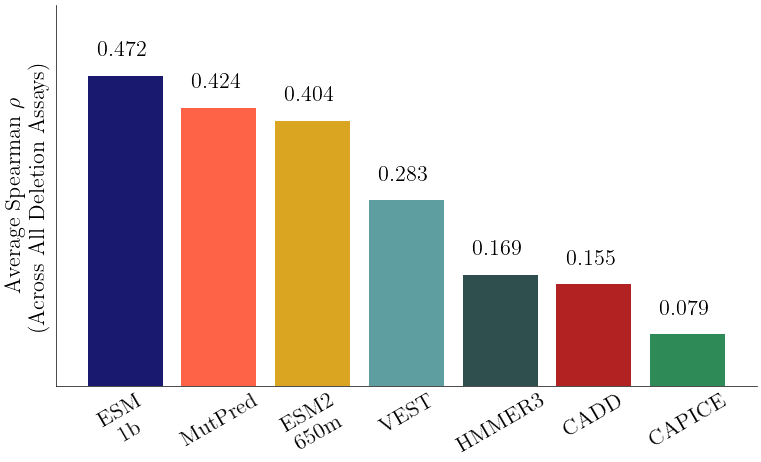

In [5]:
plt.figure(figsize=(8, 5))
corrs = {y: np.round(np.mean([dms_corr[x][y] for x in dms_corr]), 3) for y in dms_corr["A4_Aggregation"].keys()}
corrs = {k: v for k, v in sorted(corrs.items(), key=lambda item: -item[1])}

# plot data
plt.bar(corrs.keys(), corrs.values(), 
        color=colors)

# label average spearman corr
for i, method in enumerate(corrs.keys()):
    if len(str(corrs[method])) == 4:
        corrs[method] = str(corrs[method]) + "0"
    plt.text(i-.3, float(corrs[method])+0.03, corrs[method])
_=plt.xticks(range(len(corrs)),
             list(map(lambda x: x.replace(" ", "\n"), corrs.keys())),
             rotation=30)


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.ylim(0, 0.58)
plt.ylabel(r'Average Spearman $\rho$' + "\n(Across All Deletion Assays)")
plt.yticks([])
plt.tick_params(top=False, right=False, bottom=False, which="both")
plt.tight_layout()
plt.savefig("../figures/benchmarkinga.pdf")

## Within assay

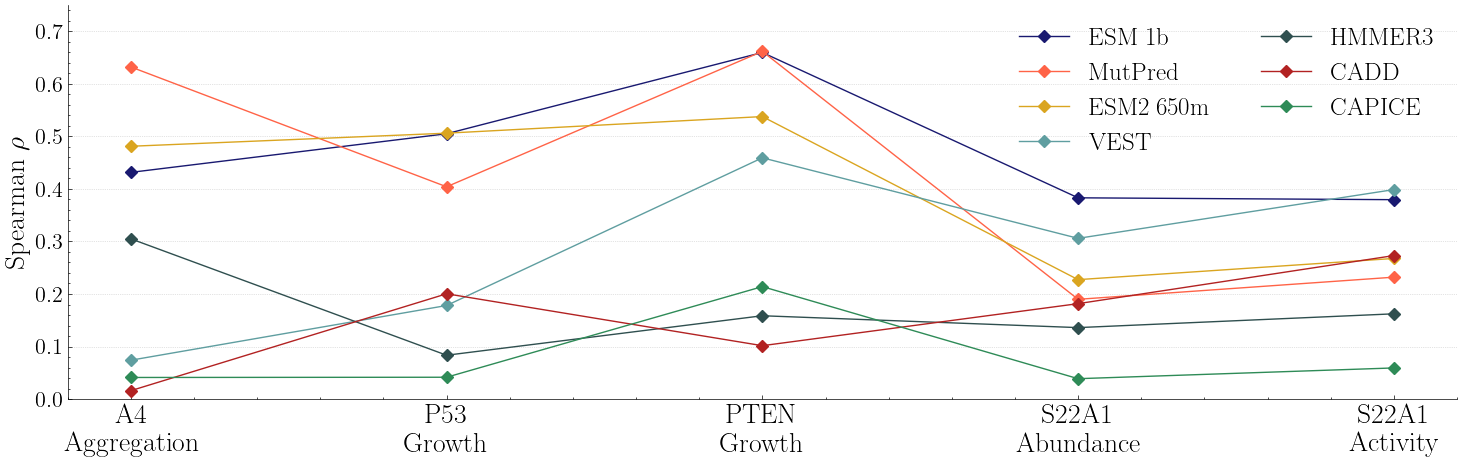

In [6]:
# construct data
all_corrs = []
for assay in dms_corr:
    assay_df = pd.DataFrame.from_dict(dms_corr[assay], orient='index').reset_index().rename(columns={"index": "Method", 0: "Spearman"})
    assay_df["Assay"] = assay
    all_corrs.append(assay_df)
df = pd.concat(all_corrs, axis=0, ignore_index=True)
df = df[df.Assay != "Average\nPerformance"]

assays = df.Assay.unique()
method_corr = {}
for method in corrs.keys():
    method_corr[method] = list(df[(df.Method == method)].sort_values(by="Assay").Spearman)

plt.figure(figsize=(15, 5))

for i, method in enumerate(corrs):
    plt.plot(range(len(assays)), method_corr[method], color=colors[i], label=method, marker='D')
    
plt.ylabel(r'Spearman $\rho$', fontsize=20)
plt.xticks(range(len(assays)), [x.replace("_", "\n") for x in assays], fontsize=20)
plt.grid(True, axis='y', linestyle=':', alpha=0.7)
plt.ylim(0, 0.75)

plt.tight_layout()
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tick_params(top=False, right=False, which="both")

legend = plt.legend(ncols=2, fontsize=18, facecolor="white", loc='best')
frame = legend.get_frame()
frame.set_color('white')
plt.savefig("../figures/benchmarkingb.pdf")